# Employee Attrition Modelling Pipeline

This notebook builds a leakage-safe modelling pipeline for the employee attrition classification task using the reduced-column dataset logic from `EDA_rm_col.ipynb`.

## Scope
- Use the no-PCA path
- Compare several classifiers, including blackbox models
- Validate with stratified cross-validation
- Tune the strongest finalists
- Evaluate on a held-out test set
- End with a recommendation for both the strongest overall benchmark and the strongest blackbox candidate

## Why this notebook differs from the EDA notebook
- Preprocessing is wrapped inside sklearn pipelines so train/test leakage is avoided
- Class imbalance is handled with imbalance-aware metrics and class weights
- Model selection is based primarily on PR-AUC because attrition is the minority class


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13


## 1. Load The Reduced-Column Dataset

The reduced version follows the feature removal choices already documented in `EDA_rm_col.ipynb`:

- Remove constant columns
- Remove identifier / non-informative columns
- Remove high-VIF or overlapping-meaning columns:
  `JobLevel`, `YearsAtCompany`, `WorkLifeBalance`, `MonthlyIncome`,
  `PerformanceRating`, `JobInvolvement`, `HourlyRate`, `DailyRate`


In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

original_shape = df.shape
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
cols_to_remove = [
    "EmployeeCount",
    "StandardHours",
    "EmployeeNumber",
    "Over18",
    "JobLevel",
    "YearsAtCompany",
    "WorkLifeBalance",
    "MonthlyIncome",
    "PerformanceRating",
    "JobInvolvement",
    "HourlyRate",
    "DailyRate",
]

df = df.drop(columns=constant_columns, errors="ignore")
df = df.drop(columns=cols_to_remove, errors="ignore")

print(f"Original shape: {original_shape}")
print(f"Shape after reductions: {df.shape}")
print(f"Constant columns removed: {constant_columns}")
print(f"Configured columns removed: {cols_to_remove}")
print()
print("Target distribution:")
print(df["Attrition"].value_counts())

df.head()


Original shape: (1470, 35)
Shape after reductions: (1470, 23)
Constant columns removed: ['EmployeeCount', 'Over18', 'StandardHours']
Configured columns removed: ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18', 'JobLevel', 'YearsAtCompany', 'WorkLifeBalance', 'MonthlyIncome', 'PerformanceRating', 'JobInvolvement', 'HourlyRate', 'DailyRate']

Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,Sales Executive,...,8,Yes,11,1,0,8,0,4,0,5
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,Research Scientist,...,1,No,23,4,1,10,3,7,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,Laboratory Technician,...,6,Yes,15,2,0,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,Research Scientist,...,1,Yes,11,3,0,8,3,7,3,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,Laboratory Technician,...,9,No,12,4,1,6,3,2,2,2


In [3]:
X = df.drop(columns=["Attrition"]).copy()
y = df["Attrition"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Positive rate in full data:", round(y.mean(), 4))
print("Positive rate in train:", round(y_train.mean(), 4))
print("Positive rate in test:", round(y_test.mean(), 4))
print()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Training shape: (1176, 22)
Test shape: (294, 22)
Positive rate in full data: 0.1612
Positive rate in train: 0.1616
Positive rate in test: 0.1599

Numeric features: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## 2. Modelling Strategy

A few choices here are intentional:

- `PR-AUC` is the main selection metric because attrition is the minority class.
- `ROC-AUC`, `F1`, `Recall`, `Precision`, and `Balanced Accuracy` are tracked as supporting metrics.
- Preprocessing is done inside each pipeline so cross-validation stays leakage-safe.
- For imbalance handling, the notebook leans on class weights rather than applying SMOTE outside CV.


In [4]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

candidate_models = {
    "Logistic Regression": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": False,
    },
    "KNN": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                ("model", KNeighborsClassifier(n_neighbors=11)),
            ]
        ),
        "is_blackbox": True,
    },
    "SVM (RBF)": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_scaled),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        gamma="scale",
                        class_weight="balanced",
                        probability=True,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "Random Forest": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=400,
                        min_samples_leaf=2,
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "Extra Trees": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=2,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
    "HistGradientBoosting": {
        "pipeline": Pipeline(
            steps=[
                ("prep", preprocessor_unscaled),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        learning_rate=0.05,
                        max_depth=6,
                        max_iter=300,
                        min_samples_leaf=20,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "is_blackbox": True,
    },
}

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "balanced_accuracy": "balanced_accuracy",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [5]:
cv_rows = []

for name, meta in candidate_models.items():
    scores = cross_validate(
        meta["pipeline"],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    row = {
        "model": name,
        "is_blackbox": meta["is_blackbox"],
    }
    for metric in scoring:
        row[f"cv_mean_{metric}"] = scores[f"test_{metric}"].mean()
        row[f"cv_std_{metric}"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["cv_mean_pr_auc", "cv_mean_recall", "cv_mean_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

cv_results.style.format(
    {
        col: "{:.3f}"
        for col in cv_results.columns
        if col.startswith("cv_mean_") or col.startswith("cv_std_")
    }
)


,model,is_blackbox,cv_mean_pr_auc,cv_std_pr_auc,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_f1,cv_std_f1,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_balanced_accuracy,cv_std_balanced_accuracy
0,Logistic Regression,False,0.601,0.072,0.826,0.024,0.501,0.012,0.742,0.056,0.380,0.025,0.753,0.011
1,SVM (RBF),True,0.565,0.101,0.811,0.031,0.543,0.052,0.600,0.051,0.499,0.068,0.741,0.030
2,Random Forest,True,0.561,0.080,0.799,0.043,0.402,0.097,0.274,0.077,0.790,0.098,0.630,0.039
3,Extra Trees,True,0.536,0.083,0.799,0.040,0.478,0.126,0.395,0.141,0.652,0.101,0.677,0.064
4,HistGradientBoosting,True,0.513,0.062,0.773,0.033,0.415,0.110,0.316,0.093,0.615,0.119,0.640,0.047
5,KNN,True,0.410,0.070,0.719,0.035,0.185,0.100,0.105,0.062,1.000,0.000,0.553,0.031


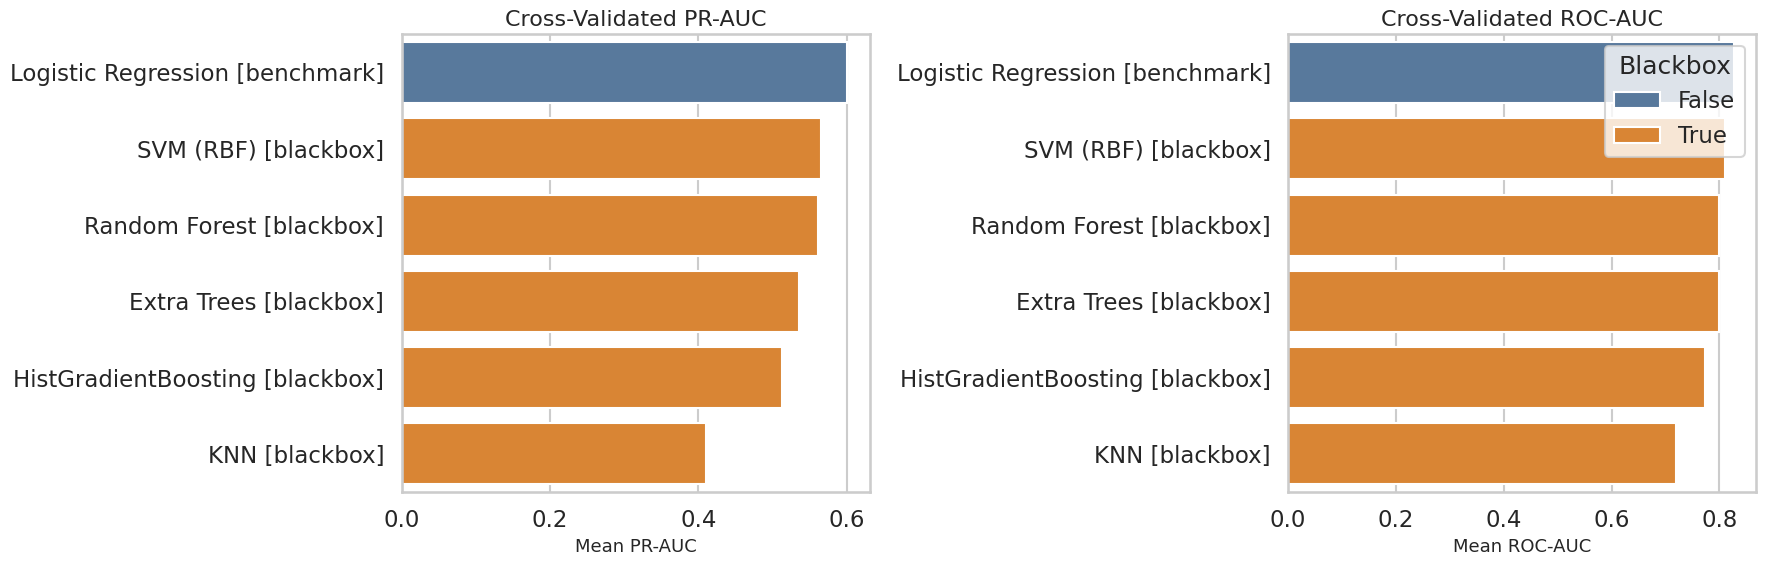

In [6]:
plot_df = cv_results.copy()
plot_df["model_label"] = np.where(
    plot_df["is_blackbox"],
    plot_df["model"] + " [blackbox]",
    plot_df["model"] + " [benchmark]",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=plot_df,
    y="model_label",
    x="cv_mean_pr_auc",
    hue="is_blackbox",
    dodge=False,
    palette=["#4C78A8", "#F58518"],
    ax=axes[0],
)
axes[0].set_title("Cross-Validated PR-AUC")
axes[0].set_xlabel("Mean PR-AUC")
axes[0].set_ylabel("")
axes[0].legend_.remove()

sns.barplot(
    data=plot_df,
    y="model_label",
    x="cv_mean_roc_auc",
    hue="is_blackbox",
    dodge=False,
    palette=["#4C78A8", "#F58518"],
    ax=axes[1],
)
axes[1].set_title("Cross-Validated ROC-AUC")
axes[1].set_xlabel("Mean ROC-AUC")
axes[1].set_ylabel("")
axes[1].legend(title="Blackbox")

plt.tight_layout()
plt.show()


In [7]:
best_cv_overall = cv_results.iloc[0]
best_cv_blackbox = (
    cv_results[cv_results["is_blackbox"]]
    .sort_values(["cv_mean_pr_auc", "cv_mean_recall", "cv_mean_roc_auc"], ascending=False)
    .iloc[0]
)

print("Best overall CV model:")
print(best_cv_overall[["model", "cv_mean_pr_auc", "cv_mean_roc_auc", "cv_mean_recall"]])
print()
print("Best blackbox CV model:")
print(best_cv_blackbox[["model", "cv_mean_pr_auc", "cv_mean_roc_auc", "cv_mean_recall"]])


Best overall CV model:
model              Logistic Regression
cv_mean_pr_auc                0.600528
cv_mean_roc_auc               0.826391
cv_mean_recall                0.742105
Name: 0, dtype: object

Best blackbox CV model:
model              SVM (RBF)
cv_mean_pr_auc      0.565168
cv_mean_roc_auc      0.81063
cv_mean_recall           0.6
Name: 1, dtype: object


## 3. Hyperparameter Tuning

To keep the notebook efficient but still iterative, I tune:

- the top 2 models overall by cross-validated PR-AUC
- plus the top blackbox model if it is not already in that top 2


In [8]:
finalists = cv_results["model"].head(2).tolist()
best_blackbox_name = best_cv_blackbox["model"]
if best_blackbox_name not in finalists:
    finalists.append(best_blackbox_name)

finalists


['Logistic Regression', 'SVM (RBF)']

In [9]:
search_spaces = {
    "Logistic Regression": {
        "model__C": np.logspace(-2, 2, 10),
        "model__solver": ["lbfgs"],
        "model__class_weight": ["balanced"],
    },
    "KNN": {
        "model__n_neighbors": [5, 7, 9, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1, 2, 5, 10],
        "model__gamma": ["scale", 0.01, 0.03, 0.05, 0.1],
    },
    "Random Forest": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    },
    "Extra Trees": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
        "model__class_weight": ["balanced", "balanced_subsample"],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
        "model__max_depth": [None, 4, 6, 8],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [10, 20, 30],
        "model__l2_regularization": [0.0, 0.1, 0.5, 1.0],
        "model__max_iter": [200, 300, 400],
    },
}

n_iter_lookup = {
    "Logistic Regression": 10,
    "KNN": 10,
    "SVM (RBF)": 10,
    "Random Forest": 12,
    "Extra Trees": 12,
    "HistGradientBoosting": 12,
}

tuned_searches = {}
tuned_rows = []

for name in finalists:
    search = RandomizedSearchCV(
        estimator=candidate_models[name]["pipeline"],
        param_distributions=search_spaces[name],
        n_iter=n_iter_lookup[name],
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    tuned_searches[name] = search

    test_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= 0.5).astype(int)

    tuned_rows.append(
        {
            "model": name,
            "is_blackbox": candidate_models[name]["is_blackbox"],
            "best_params": search.best_params_,
            "cv_best_pr_auc": search.best_score_,
            "test_pr_auc": average_precision_score(y_test, test_proba),
            "test_roc_auc": roc_auc_score(y_test, test_proba),
            "test_f1": f1_score(y_test, test_pred),
            "test_recall": recall_score(y_test, test_pred),
            "test_precision": precision_score(y_test, test_pred, zero_division=0),
            "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        }
    )

tuned_results = (
    pd.DataFrame(tuned_rows)
    .sort_values(["test_pr_auc", "test_recall", "test_roc_auc"], ascending=False)
    .reset_index(drop=True)
)

tuned_results


,model,is_blackbox,best_params,cv_best_pr_auc,test_pr_auc,test_roc_auc,test_f1,test_recall,test_precision,test_balanced_accuracy
0,Logistic Regression,False,"{'model__solver': 'lbfgs', 'model__class_weigh...",0.606030,0.588650,0.808080,0.482270,0.723404,0.361702,0.740245
1,SVM (RBF),True,"{'model__gamma': 0.01, 'model__C': 2}",0.613182,0.571035,0.810836,0.411765,0.297872,0.666667,0.634766


In [10]:
best_overall_final = tuned_results.iloc[0]
best_blackbox_final = (
    tuned_results[tuned_results["is_blackbox"]]
    .sort_values(["test_pr_auc", "test_recall", "test_roc_auc"], ascending=False)
    .iloc[0]
)

print("Best overall tuned model:")
print(best_overall_final[["model", "test_pr_auc", "test_roc_auc", "test_recall", "test_precision", "test_f1"]])
print()
print("Chosen blackbox model: SVM (RBF)")
print(tuned_results.loc[tuned_results["model"] == "SVM (RBF)", ["model", "test_pr_auc", "test_roc_auc", "test_recall", "test_precision", "test_f1"]].iloc[0])
print()
print("Chosen hyperparameters for the blackbox recommendation:")
print(tuned_searches["SVM (RBF)"].best_params_)


Best overall tuned model:
model             Logistic Regression
test_pr_auc                   0.58865
test_roc_auc                  0.80808
test_recall                  0.723404
test_precision               0.361702
test_f1                       0.48227
Name: 0, dtype: object

Chosen blackbox model: SVM (RBF)
model             SVM (RBF)
test_pr_auc        0.571035
test_roc_auc       0.810836
test_recall        0.297872
test_precision     0.666667
test_f1            0.411765
Name: 1, dtype: object

Chosen hyperparameters for the blackbox recommendation:
{'model__gamma': 0.01, 'model__C': 2}


## 4. Threshold Tuning For The Recommended Blackbox Model

The default `0.50` threshold is often not ideal for imbalanced classification.
Here I tune the threshold on the training set for the chosen blackbox finalist using the `F2` score, which places more emphasis on recall.


In [11]:
recommended_blackbox_name = "SVM (RBF)"
recommended_blackbox_estimator = tuned_searches[recommended_blackbox_name].best_estimator_

train_proba_blackbox = recommended_blackbox_estimator.predict_proba(X_train)[:, 1]
threshold_grid = np.linspace(0.20, 0.80, 61)

threshold_rows = []
for threshold in threshold_grid:
    preds = (train_proba_blackbox >= threshold).astype(int)
    precision = precision_score(y_train, preds, zero_division=0)
    recall = recall_score(y_train, preds)
    f1 = f1_score(y_train, preds)
    f2 = (
        5 * precision * recall / (4 * precision + recall)
        if (4 * precision + recall) > 0
        else 0
    )
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2,
            "balanced_accuracy": balanced_accuracy_score(y_train, preds),
        }
    )

threshold_results = pd.DataFrame(threshold_rows).sort_values(
    ["f2", "recall", "balanced_accuracy"],
    ascending=False,
)

threshold_results.head(10)


,threshold,precision,recall,f1,f2,balanced_accuracy
2,0.22,0.546099,0.810526,0.652542,0.738964,0.840354
1,0.21,0.527027,0.821053,0.641975,0.738636,0.839532
0,0.20,0.518152,0.826316,0.636917,0.738476,0.839121
8,0.28,0.644444,0.763158,0.698795,0.736041,0.841011
7,0.27,0.633188,0.763158,0.692124,0.733064,0.838983
6,0.26,0.616034,0.768421,0.683841,0.732197,0.838064
4,0.24,0.573077,0.784211,0.662222,0.730392,0.835817
3,0.23,0.551095,0.794737,0.650862,0.730174,0.834995
5,0.25,0.595918,0.768421,0.671264,0.726368,0.834008
10,0.30,0.676329,0.736842,0.705290,0.723888,0.834445


In [12]:
selected_threshold = float(threshold_results.iloc[0]["threshold"])
test_proba_blackbox = recommended_blackbox_estimator.predict_proba(X_test)[:, 1]

threshold_eval_rows = []
for threshold in [0.50, selected_threshold]:
    preds = (test_proba_blackbox >= threshold).astype(int)
    threshold_eval_rows.append(
        {
            "threshold": threshold,
            "pr_auc": average_precision_score(y_test, test_proba_blackbox),
            "roc_auc": roc_auc_score(y_test, test_proba_blackbox),
            "f1": f1_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "precision": precision_score(y_test, preds, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, preds),
            "positives_predicted": int(preds.sum()),
        }
    )

threshold_test_results = pd.DataFrame(threshold_eval_rows)
threshold_test_results


,threshold,pr_auc,roc_auc,f1,recall,precision,balanced_accuracy,positives_predicted
0,0.50,0.571035,0.810836,0.411765,0.297872,0.666667,0.634766,21
1,0.22,0.571035,0.810836,0.513274,0.617021,0.439394,0.733612,66


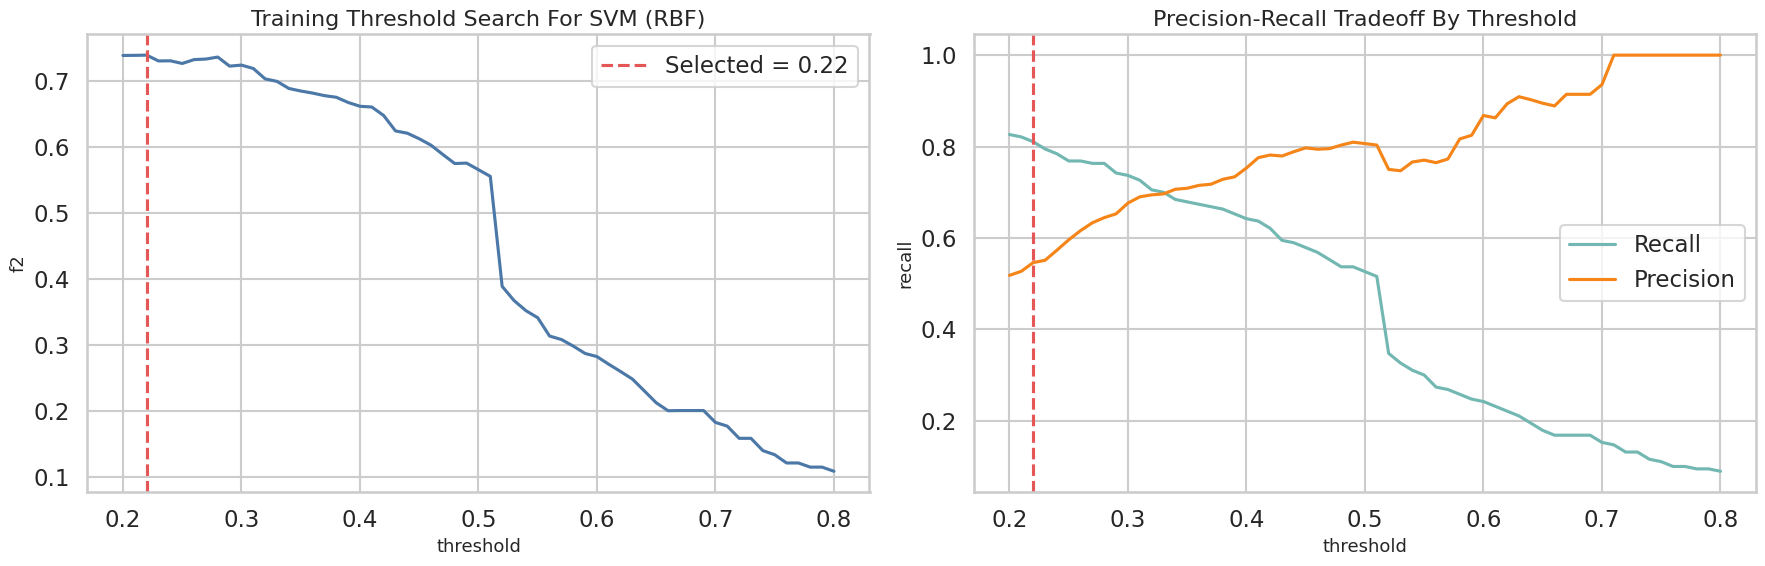

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="f2",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].axvline(selected_threshold, color="#E45756", linestyle="--", label=f"Selected = {selected_threshold:.2f}")
axes[0].set_title(f"Training Threshold Search For {recommended_blackbox_name}")
axes[0].legend()

sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="recall",
    ax=axes[1],
    color="#72B7B2",
    label="Recall",
)
sns.lineplot(
    data=threshold_results.sort_values("threshold"),
    x="threshold",
    y="precision",
    ax=axes[1],
    color="#F58518",
    label="Precision",
)
axes[1].axvline(selected_threshold, color="#E45756", linestyle="--")
axes[1].set_title("Precision-Recall Tradeoff By Threshold")

plt.tight_layout()
plt.show()


## 5. Final Evaluation Plots


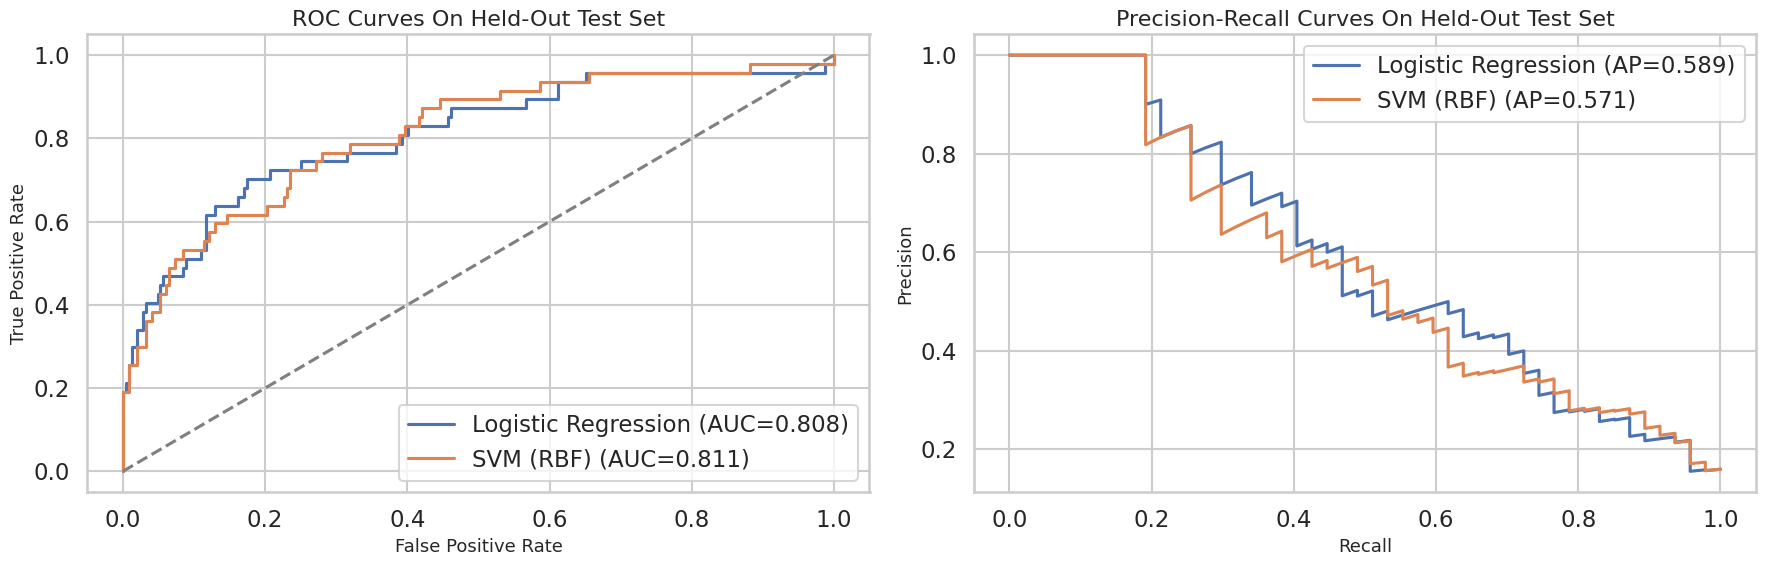

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for name in finalists:
    estimator = tuned_searches[name].best_estimator_
    proba = estimator.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba)

    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    axes[1].plot(recall_curve, precision_curve, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curves On Held-Out Test Set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall Curves On Held-Out Test Set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


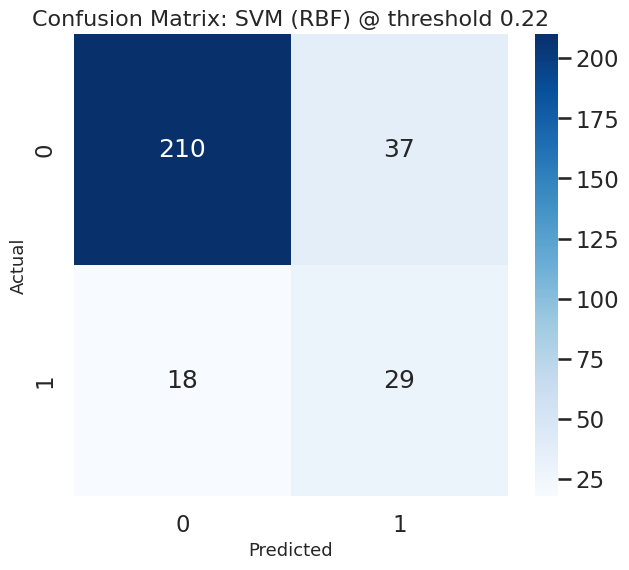

              precision    recall  f1-score   support

No Attrition       0.92      0.85      0.88       247
   Attrition       0.44      0.62      0.51        47

    accuracy                           0.81       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.81      0.82       294



In [15]:
final_blackbox_preds = (test_proba_blackbox >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, final_blackbox_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {recommended_blackbox_name} @ threshold {selected_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, final_blackbox_preds, target_names=["No Attrition", "Attrition"]))


## 6. Recommendation

The next cell prints a compact conclusion that you can reuse in your capstone write-up.


In [16]:
overall_model_name = best_overall_final["model"]
blackbox_model_name = "SVM (RBF)"

overall_summary = tuned_results.loc[tuned_results["model"] == overall_model_name].iloc[0]
blackbox_summary = tuned_results.loc[tuned_results["model"] == blackbox_model_name].iloc[0]
threshold_summary = threshold_test_results.loc[
    threshold_test_results["threshold"] == selected_threshold
].iloc[0]

print("Overall benchmark winner")
print(
    f"- {overall_model_name}: PR-AUC={overall_summary['test_pr_auc']:.3f}, "
    f"ROC-AUC={overall_summary['test_roc_auc']:.3f}, "
    f"Recall={overall_summary['test_recall']:.3f}, "
    f"Precision={overall_summary['test_precision']:.3f}, "
    f"F1={overall_summary['test_f1']:.3f}"
)
print()
print("Recommended blackbox model")
print(
    f"- {blackbox_model_name}: PR-AUC={blackbox_summary['test_pr_auc']:.3f}, "
    f"ROC-AUC={blackbox_summary['test_roc_auc']:.3f}, "
    f"Recall@0.50={blackbox_summary['test_recall']:.3f}, "
    f"Precision@0.50={blackbox_summary['test_precision']:.3f}, "
    f"F1@0.50={blackbox_summary['test_f1']:.3f}"
)
print(
    f"- Threshold-adjusted blackbox setting ({selected_threshold:.2f}) gives "
    f"Recall={threshold_summary['recall']:.3f}, "
    f"Precision={threshold_summary['precision']:.3f}, "
    f"F1={threshold_summary['f1']:.3f}, "
    f"Balanced Accuracy={threshold_summary['balanced_accuracy']:.3f}"
)
print()
print("Recommendation")
print(
    f"- Keep {overall_model_name} as the performance benchmark."
)
print(
    f"- Use {blackbox_model_name} as the blackbox handoff model for the next XAI phase."
)


Overall benchmark winner
- Logistic Regression: PR-AUC=0.589, ROC-AUC=0.808, Recall=0.723, Precision=0.362, F1=0.482

Recommended blackbox model
- SVM (RBF): PR-AUC=0.571, ROC-AUC=0.811, Recall@0.50=0.298, Precision@0.50=0.667, F1@0.50=0.412
- Threshold-adjusted blackbox setting (0.22) gives Recall=0.617, Precision=0.439, F1=0.513, Balanced Accuracy=0.734

Recommendation
- Keep Logistic Regression as the performance benchmark.
- Use SVM (RBF) as the blackbox handoff model for the next XAI phase.
